# Example: Single Contract Payoff and Profit
In this example, we will analyze the payoff and profit at expiration of __all four__ single-contract option positions: long call, short call, long put, and short put.

> __Learning Objectives:__
> 
> By the end of this example, you should be able to:
> * __Construct option contract models__ for calls and puts in both directions, by reading premiums off a real options chain and specifying the strike price and the position direction $\theta$.
> * __Compute payoff and profit diagrams__ from the left boundary $S_{T}=0$ outward, which is where the put positions attain their finite bounds, and convert per-share quantities to per-contract dollars using the deliverable $q$.
> * __Verify the analytical results.__ Compute the breakeven prices $K+C_{0}$ and $K-P_{0}$, and the maximum profit and maximum loss of each position, then check each one numerically against the computed diagrams.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
To start, load the options data using [the `MyOptionsChainDataSet(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyOptionsChainDataSet) and store the data in the `metadata::Dict{String,Any}` and `optionschain::DataFrame` variables.

In [2]:
metadata, optionschain = let
    
    # initialize -
    options_dataset = MyOptionsChainDataSet(ticker="amd");
    metadata = options_dataset.metadata;
    optionschain = options_dataset.data;

    (metadata, optionschain) # return
end;

What's in the metadata dictionary?

In [3]:
metadata |> keys

KeySet for a Dict{String, Any} with 10 entries. Keys:
  "DTE"
  "purchase_date"
  "historical_volatility"
  "underlying_share_price_ask"
  "source"
  "underlying_share_price_bid"
  "is_weekly"
  "atm_IV"
  "expiration_date"
  "underlying_share_price_mid"

What about the optionschain variable?

In [4]:
optionschain

Row,Strike,Moneyness,Bid,Mid,Ask,Last,Volume,Open Int,IV,Delta,Type
,Float64,Float64,Float64,Float64,Float64,Float64,String7,String7,Float64,Float64,String7
1,25.0,0.8907,203.1,204.0,204.9,209.72,0,419,2.1122,0.9989,Call
2,30.0,0.8688,198.2,199.05,199.9,206.3,0,163,1.9784,0.9985,Call
3,35.0,0.847,193.2,193.98,194.75,199.75,0,17,0.0,0.0,Call
4,40.0,0.8251,188.3,189.1,189.9,176.24,0,18,1.6654,0.9985,Call
5,45.0,0.8033,183.25,184.13,185.0,174.11,0,318,1.5375,0.9985,Call
6,50.0,0.7814,178.4,179.1,179.8,167.46,0,691,1.2356,0.9996,Call
7,55.0,0.7596,173.35,174.13,174.9,177.43,0,176,1.0885,0.9998,Call
8,60.0,0.7377,168.5,169.3,170.1,162.15,0,332,1.3802,0.9967,Call
9,65.0,0.7158,163.45,164.33,165.2,175.38,0,180,1.2927,0.9967,Call


### Constants
Finally, let's set the constants we'll use later in this notebook. The comments describe the constants, their units, and permissible values:

In [5]:
Sₒ = metadata["underlying_share_price_mid"] |> x-> parse(Float64,x); # recorded underlying share price (USD/share)
q = 100; # deliverable multiplier (shares/contract) for a standard US equity option
DTE = metadata["DTE"] |> x-> parse(Float64,x); # days to expiration (days)

#### Does the chain agree with its own recorded share price?
Before using a data set, check that it is internally consistent. The chain carries a `Moneyness` column for every row, defined for a call as the fractional distance of the strike below the underlying:

$$
M(K) = \frac{S-K}{S}\quad\Longrightarrow\quad S = \frac{K}{1-M(K)}
$$

where $M(K)$ is the recorded moneyness at strike $K$ and $S$ is the underlying price the chain was built from. Every row therefore implies its own value of $S$, and those values should agree with each other __and__ with the recorded `underlying_share_price_mid`. Let's check:

In [6]:
implied_spot_table = let

    # initialize -
    calls = filter([:Type] => (t) -> (t == "Call"), optionschain);
    calls = filter([:Strike] => (K) -> (150.0 ≤ K ≤ 300.0), calls); # liquid strikes near the money

    # each row implies a share price: S = K/(1-M) -
    implied = calls.Strike ./ (1.0 .- calls.Moneyness);

    # return a small summary -
    DataFrame(
        quantity = ["recorded underlying_share_price_mid", "implied by Moneyness (mean)", "implied by Moneyness (min)", "implied by Moneyness (max)", "difference (implied mean - recorded)"],
        value = round.([Sₒ, sum(implied)/length(implied), minimum(implied), maximum(implied), sum(implied)/length(implied) - Sₒ], digits = 4)
    );
end

Row,quantity,value
,String,Float64
1,recorded underlying_share_price_mid,225.78
2,implied by Moneyness (mean),228.74
3,implied by Moneyness (min),228.728
4,implied by Moneyness (max),228.754
5,difference (implied mean - recorded),2.9598


The implied values agree with each other to within about three hundredths of a dollar (min $228.728$, max $228.754$ in the table above), which is what rounding of the `Moneyness` column to four decimals produces. They do __not__ agree with the recorded `underlying_share_price_mid`.

> __What this means.__ The option quotes were captured against an underlying price near the implied value, while the `underlying_share_price_mid` field records a different one. The two observations are not synchronized: they come from different moments, or the field was copied from a different snapshot. This is ordinary in real market data and it is exactly why we check.
>
> __What it does and does not affect.__ Nothing in this notebook depends on it. Payoff and profit at expiration are functions of $S_{T}$, $K$, and the premium only; the price of the underlying _today_ never enters. It would matter a great deal for anything that compares a premium to the current price, which is what L9a does, so we record the discrepancy now rather than discovering it later.

___

## Task 1: Call Contracts, Long and Short
In this task, we analyze the payoff and profit of a call contract held __long__ ($\theta=+1$) and sold __short__ ($\theta=-1$).

Let's extract the call option data from the `optionschain::DataFrame` dataset at a chosen strike, and build two instances of [the `MyAmericanCallContractModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.MyAmericanCallContractModel) with [the `build(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.build-Tuple{Type{MyAmericanCallContractModel},%20NamedTuple}), one for each direction.

> __Why an American contract model here?__ At expiration, an American and a European contract of the same type and strike have the __same__ payoff, namely the intrinsic value: there is no remaining time in which the extra exercise right could be used. Exercise style changes the premium and the pre-expiration exercise path, not the terminal payoff, so either model type produces the diagrams below. L9a and L9b take up the difference.

In [7]:
Kc, C₀, call_long, call_short = let

    # initialize -
    options_dataset = optionschain;
    Kc = 230.0; # strike price (USD/share)
    C₀ = filter([:Strike,:Type] => (x,y) -> (x == Kc && y == "Call"), options_dataset)[1,:Mid]; # premium (USD/share)

    # build one model per direction: θ = +1 long, θ = -1 short -
    call_long  = build(MyAmericanCallContractModel, (K = Kc, premium = C₀, sense =  1, copy = 1));
    call_short = build(MyAmericanCallContractModel, (K = Kc, premium = C₀, sense = -1, copy = 1));

    (Kc, C₀, call_long, call_short); # return
end;

The buyer pays this premium and the seller collects it. Premiums are quoted __per share__, so the cash that actually moves is the premium multiplied by the deliverable $q$:

In [8]:
let
    println("Call strike K       : $(Kc) USD/share");
    println("Call premium C₀     : $(round(C₀, digits=2)) USD/share");
    println("Cash per contract   : $(round(q*C₀, digits=2)) USD  (= q × C₀ with q = $(q) shares/contract)");
    println("Breakeven K + C₀    : $(round(Kc + C₀, digits=2)) USD/share");
    println("Days to expiration  : $(DTE) days");
end

Call strike K       : 230.0 USD/share
Call premium C₀     : 21.58 USD/share
Cash per contract   : 2158.0 USD  (= q × C₀ with q = 100 shares/contract)
Breakeven K + C₀    : 251.58 USD/share
Days to expiration  : 58.0 days


### Visualize Payoff and Profit
Next, we use [the `payoff(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.payoff) and [the `profit(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.profit) to evaluate both positions from the __left boundary__ $S_{T}=0$ outward.

> __Plot all the way to zero.__ The underlying price satisfies $S_{T}\geq{0}$, and that boundary is not decoration: it is what makes a short put's loss finite and a long straddle's downside profit finite. A diagram that starts partway up, at say half the current share price, hides the very boundary that decides the answer. We therefore sweep $S_{T}$ from $0$ to twice the strike.

In [9]:
S_expiration, payoff_call, profit_call_long, profit_call_short = let

    # sweep from the left boundary S_T = 0 to S_T = 2K -
    S_expiration = range(0.0, stop = 2.0*Kc, step = 0.5) |> collect; # USD/share

    payoff_call       = payoff([call_long],  S_expiration);  # per share
    profit_call_long  = profit([call_long],  S_expiration);  # per share
    profit_call_short = profit([call_short], S_expiration);  # per share

    (S_expiration, payoff_call, profit_call_long, profit_call_short); # return
end;

Let's plot the long payoff against the long and short profit using [the `plot(...)` function from the `Plots.jl` package](https://github.com/JuliaPlots/Plots.jl). The two profit curves are exact reflections of one another about zero: what the buyer gains, the seller loses.

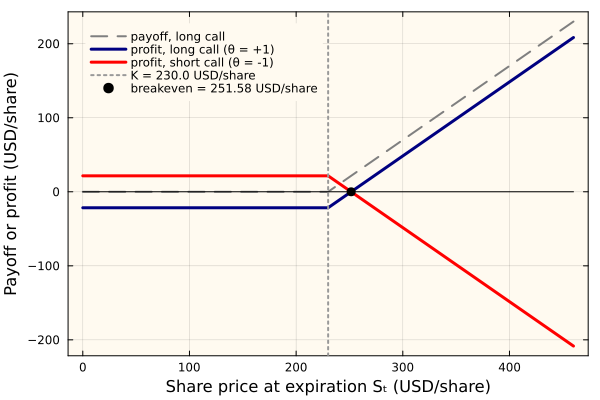

In [10]:
let
    breakeven = Kc + C₀;

    plot(S_expiration, payoff_call[:,2], lw = 2, c = :gray50, ls = :dash, label = "payoff, long call",
        bg = "floralwhite", background_color_outside = "white", framestyle = :box, fg_legend = :transparent);
    plot!(S_expiration, profit_call_long[:,2],  lw = 3, c = :navyblue, label = "profit, long call (θ = +1)");
    plot!(S_expiration, profit_call_short[:,2], lw = 3, c = :red,      label = "profit, short call (θ = -1)");
    plot!(S_expiration, zeros(length(S_expiration)), lw = 1, c = :black, label = "");

    vline!([Kc], lw = 2, c = :gray60, ls = :dot, label = "K = $(Kc) USD/share");
    scatter!([breakeven], [0.0], c = :black, ms = 5,
        label = "breakeven = $(round(breakeven, digits=2)) USD/share");

    xlabel!("Share price at expiration Sₜ (USD/share)", fontsize = 18);
    ylabel!("Payoff or profit (USD/share)", fontsize = 18);
end

### Breakeven Analysis for a Call Contract
The breakeven is the terminal price at which profit is exactly zero. Start from the long call profit and set it to zero:
$$
\begin{align*}
\Pi_{T}^{\,c,+1}(S_{T}) &= h_{c}(S_{T};K) - C_{0}\\
0 &= \max\left(S_{T}-K,\,0\right) - C_{0}\\
C_{0} &= S_{T}-K \quad\text{(the exercised branch, since } C_{0}>0 \text{ requires } S_{T}>K)\\
S_{T} &= K + C_{0}
\end{align*}
$$
The short call profit is $\Pi_{T}^{\,c,-1} = -\Pi_{T}^{\,c,+1}$, so it vanishes at the same price. __The two positions share a breakeven and disagree about which side of it they want.__

The bounds follow from the same expression. As $S_{T}\to\infty$ the long profit grows without bound and the short loss does the same, while at $S_{T}=0$ the call expires worthless and the long simply loses the premium. Let's verify all of it numerically rather than trusting the algebra:

In [11]:
let
    breakeven   = Kc + C₀;
    i_be        = argmin(abs.(S_expiration .- breakeven));
    i_zero      = argmin(abs.(S_expiration .- 0.0));

    # 1. profit is (approximately) zero at the analytical breakeven -
    @assert abs(profit_call_long[i_be, 2]) ≤ 0.5   "long call profit is not zero at K + C₀"
    @assert abs(profit_call_short[i_be, 2]) ≤ 0.5  "short call profit is not zero at K + C₀"

    # 2. the two directions are exact mirror images -
    @assert all(isapprox.(profit_call_long[:,2], -profit_call_short[:,2]; atol = 1e-10)) "long and short call profits are not mirror images"

    # 3. maximum loss of the long call is the premium, attained wherever S_T ≤ K -
    @assert isapprox(minimum(profit_call_long[:,2]), -C₀; atol = 1e-10) "long call maximum loss is not C₀"
    @assert isapprox(profit_call_long[i_zero, 2], -C₀; atol = 1e-10)    "long call does not lose exactly C₀ at S_T = 0"

    # 4. maximum profit of the short call is the premium -
    @assert isapprox(maximum(profit_call_short[:,2]), C₀; atol = 1e-10) "short call maximum profit is not C₀"

    println("All call-contract checks passed.");
    println("  breakeven                       : $(round(breakeven, digits=2)) USD/share");
    println("  long call max loss              : $(round(minimum(profit_call_long[:,2]), digits=2)) USD/share  (= -C₀)");
    println("  long call profit at Sₜ = 2K     : $(round(profit_call_long[end,2], digits=2)) USD/share  (grows without bound)");
    println("  short call max profit           : $(round(maximum(profit_call_short[:,2]), digits=2)) USD/share  (= C₀)");
    println("  short call profit at Sₜ = 2K    : $(round(profit_call_short[end,2], digits=2)) USD/share  (falls without bound)");
end

All call-contract checks passed.
  breakeven                       : 251.58 USD/share
  long call max loss              : -21.58 USD/share  (= -C₀)
  long call profit at Sₜ = 2K     : 208.42 USD/share  (grows without bound)
  short call max profit           : 21.58 USD/share  (= C₀)
  short call profit at Sₜ = 2K    : -208.42 USD/share  (falls without bound)


___

## Task 2: Put Contracts, Long and Short
In this task, we repeat the analysis for a put contract held __long__ ($\theta=+1$) and sold __short__ ($\theta=-1$), using [the `MyAmericanPutContractModel` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/derivatives/#VLQuantitativeFinancePackage.MyAmericanPutContractModel).

The put is where the domain $S_{T}\geq{0}$ starts to matter, so watch what happens at the left edge of the diagram.

In [12]:
Kp, P₀, put_long, put_short = let

    # initialize -
    options_dataset = optionschain;
    Kp = 220.0; # strike price (USD/share)
    P₀ = filter([:Strike,:Type] => (x,y) -> (x == Kp && y == "Put"), options_dataset)[1,:Mid]; # premium (USD/share)

    # build one model per direction: θ = +1 long, θ = -1 short -
    put_long  = build(MyAmericanPutContractModel, (K = Kp, premium = P₀, sense =  1, copy = 1));
    put_short = build(MyAmericanPutContractModel, (K = Kp, premium = P₀, sense = -1, copy = 1));

    (Kp, P₀, put_long, put_short); # return
end;

Again, the quoted premium is per share and the cash that moves is $q$ times larger:

In [13]:
let
    println("Put strike K        : $(Kp) USD/share");
    println("Put premium P₀      : $(round(P₀, digits=2)) USD/share");
    println("Cash per contract   : $(round(q*P₀, digits=2)) USD  (= q × P₀ with q = $(q) shares/contract)");
    println("Breakeven K - P₀    : $(round(Kp - P₀, digits=2)) USD/share");
    println("Short put worst loss: $(round(-(Kp - P₀), digits=2)) USD/share = $(round(-q*(Kp - P₀), digits=2)) USD/contract, at Sₜ = 0 (a finite loss)");
end

Put strike K        : 220.0 USD/share
Put premium P₀      : 16.33 USD/share
Cash per contract   : 1633.0 USD  (= q × P₀ with q = 100 shares/contract)
Breakeven K - P₀    : 203.67 USD/share
Short put worst loss: -203.67 USD/share = -20367.0 USD/contract, at Sₜ = 0 (a finite loss)


### Visualize Payoff and Profit
We sweep the same window, from $S_{T}=0$ to twice the strike.

In [14]:
S_expiration_put, payoff_put, profit_put_long, profit_put_short = let

    S_expiration_put = range(0.0, stop = 2.0*Kp, step = 0.5) |> collect; # USD/share

    payoff_put       = payoff([put_long],  S_expiration_put);  # per share
    profit_put_long  = profit([put_long],  S_expiration_put);  # per share
    profit_put_short = profit([put_short], S_expiration_put);  # per share

    (S_expiration_put, payoff_put, profit_put_long, profit_put_short); # return
end;

The left edge of this plot is the whole point. Both put curves __stop__: they run into the vertical axis at $S_{T}=0$ and go no further, because a share price cannot be negative.

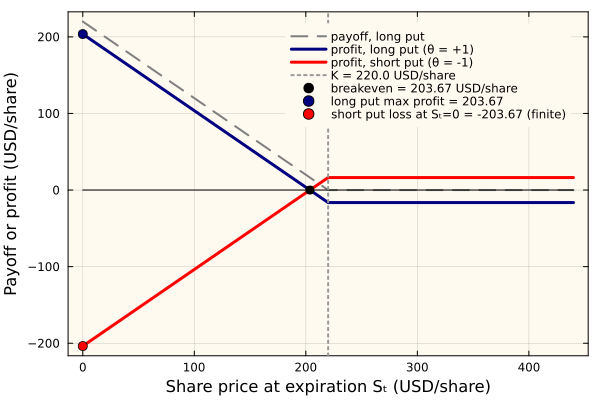

In [15]:
let
    breakeven = Kp - P₀;

    plot(S_expiration_put, payoff_put[:,2], lw = 2, c = :gray50, ls = :dash, label = "payoff, long put",
        bg = "floralwhite", background_color_outside = "white", framestyle = :box, fg_legend = :transparent);
    plot!(S_expiration_put, profit_put_long[:,2],  lw = 3, c = :navyblue, label = "profit, long put (θ = +1)");
    plot!(S_expiration_put, profit_put_short[:,2], lw = 3, c = :red,      label = "profit, short put (θ = -1)");
    plot!(S_expiration_put, zeros(length(S_expiration_put)), lw = 1, c = :black, label = "");

    vline!([Kp], lw = 2, c = :gray60, ls = :dot, label = "K = $(Kp) USD/share");
    scatter!([breakeven], [0.0], c = :black, ms = 5,
        label = "breakeven = $(round(breakeven, digits=2)) USD/share");
    scatter!([0.0], [Kp - P₀], c = :navyblue, ms = 5,
        label = "long put max profit = $(round(Kp - P₀, digits=2))");
    scatter!([0.0], [P₀ - Kp], c = :red, ms = 5,
        label = "short put loss at Sₜ=0 = $(round(P₀ - Kp, digits=2)) (finite)");

    xlabel!("Share price at expiration Sₜ (USD/share)", fontsize = 18);
    ylabel!("Payoff or profit (USD/share)", fontsize = 18);
end

### Breakeven and Bounds for a Put Contract
The breakeven derivation mirrors the call. Setting the long put profit to zero:
$$
\begin{align*}
\Pi_{T}^{\,p,+1}(S_{T}) &= h_{p}(S_{T};K) - P_{0}\\
0 &= \max\left(K-S_{T},\,0\right) - P_{0}\\
P_{0} &= K-S_{T} \quad\text{(the exercised branch, since } P_{0}>0 \text{ requires } S_{T}<K)\\
S_{T} &= K - P_{0}
\end{align*}
$$
The bounds, however, do __not__ mirror the call, and the reason is the domain:
$$
0 \leq S_{T} \quad\Longrightarrow\quad h_{p}(S_{T};K) = \left(K-S_{T}\right)^{+} \leq K
$$
The put payoff is capped by its own strike, so the long put's maximum profit is $K-P_{0}$ and the short put's maximum loss is the same finite number, both attained at $S_{T}=0$. There is no corresponding cap for the call, because $S_{T}$ has no upper bound.

> __This is the sentence to remember:__ an uncovered __short call__ has no finite terminal loss bound; a __short put__ does. The short put's bound may be large, but "large" and "unlimited" are different claims, and only one of them is true here.

Let's verify:

In [16]:
let
    breakeven = Kp - P₀;
    i_be      = argmin(abs.(S_expiration_put .- breakeven));

    # 1. profit vanishes at the analytical breakeven -
    @assert abs(profit_put_long[i_be, 2]) ≤ 0.5  "long put profit is not zero at K - P₀"

    # 2. mirror images -
    @assert all(isapprox.(profit_put_long[:,2], -profit_put_short[:,2]; atol = 1e-10)) "long and short put profits are not mirror images"

    # 3. long put maximum loss is the premium; maximum profit is K - P₀ at S_T = 0 -
    @assert isapprox(minimum(profit_put_long[:,2]), -P₀;      atol = 1e-10) "long put maximum loss is not P₀"
    @assert isapprox(maximum(profit_put_long[:,2]), Kp - P₀;  atol = 1e-10) "long put maximum profit is not K - P₀"
    @assert isapprox(profit_put_long[1,2],          Kp - P₀;  atol = 1e-10) "long put maximum profit is not attained at S_T = 0"

    # 4. the short put loss is FINITE, and equals K - P₀ in magnitude -
    @assert isapprox(minimum(profit_put_short[:,2]), P₀ - Kp; atol = 1e-10) "short put worst case is not P₀ - K"
    @assert isfinite(minimum(profit_put_short[:,2]))                        "short put worst case is not finite"

    println("All put-contract checks passed.");
    println("  breakeven                    : $(round(breakeven, digits=2)) USD/share");
    println("  long put max loss            : $(round(minimum(profit_put_long[:,2]), digits=2)) USD/share  (= -P₀)");
    println("  long put max profit at Sₜ = 0: $(round(maximum(profit_put_long[:,2]), digits=2)) USD/share  (= K - P₀, FINITE)");
    println("  short put max profit         : $(round(maximum(profit_put_short[:,2]), digits=2)) USD/share  (= P₀)");
    println("  short put worst case         : $(round(minimum(profit_put_short[:,2]), digits=2)) USD/share  = $(round(q*minimum(profit_put_short[:,2]), digits=2)) USD/contract, and it is FINITE");
end

All put-contract checks passed.
  breakeven                    : 203.67 USD/share
  long put max loss            : -16.33 USD/share  (= -P₀)
  long put max profit at Sₜ = 0: 203.67 USD/share  (= K - P₀, FINITE)
  short put max profit         : 16.33 USD/share  (= P₀)
  short put worst case         : -203.67 USD/share  = -20367.0 USD/contract, and it is FINITE


___

## The Four Positions Side by Side
Collecting the analytical results for the two contracts we built: strike, premium, maximum profit, maximum loss, and breakeven per share, with maximum loss also shown per contract.

> __Sign convention in this table.__ Losses are reported as positive __magnitudes__, which is how a risk sheet quotes them. The printed checks and the figures above report the same quantities as __signed profits__, so the short put's maximum loss of $K-P_{0}$ appears here as $203.67$ and there as $-203.67$. Same number, two conventions; read the column name.

In [17]:
four_positions = let
    DataFrame(
        position    = ["long call", "short call", "long put", "short put"],
        K           = [Kc, Kc, Kp, Kp],
        premium     = round.([C₀, C₀, P₀, P₀], digits = 2),
        max_profit  = ["unbounded", "$(round(C₀, digits=2))", "$(round(Kp - P₀, digits=2))", "$(round(P₀, digits=2))"],
        max_loss    = ["$(round(C₀, digits=2))", "unbounded", "$(round(P₀, digits=2))", "$(round(Kp - P₀, digits=2))"],
        breakeven   = round.([Kc + C₀, Kc + C₀, Kp - P₀, Kp - P₀], digits = 2),
        max_loss_per_contract = ["$(round(q*C₀, digits=2))", "unbounded", "$(round(q*P₀, digits=2))", "$(round(q*(Kp - P₀), digits=2))"]
    );
end

Row,position,K,premium,max_profit,max_loss,breakeven,max_loss_per_contract
,String,Float64,Float64,String,String,Float64,String
1,long call,230.0,21.58,unbounded,21.58,251.58,2158.0
2,short call,230.0,21.58,21.58,unbounded,251.58,unbounded
3,long put,220.0,16.33,203.67,16.33,203.67,1633.0
4,short put,220.0,16.33,16.33,203.67,203.67,20367.0


Exactly one cell in the `max_loss` column reads `unbounded`, and it is the short call.

___

## Summary
This example built all four single-contract option positions from a real options chain and analyzed their payoff and profit across finite windows from $S_{T}=0$ through $S_{T}=2K$.

> __Key Takeaways:__
>
> * __Payoff versus profit:__ payoff depends only on the strike and the terminal share price, while profit adjusts payoff by the premium paid or collected. Payoff is contractual; profit is yours.
> * __Breakevens are shared, directions are not:__ a call position breaks even at $K+C_{0}$ and a put position at $K-P_{0}$, whichever side you take. Long and short profits are exact reflections about zero, so the two counterparties agree on the breakeven price and disagree about everything else.
> * __The domain $S_{T}\geq{0}$ decides the bounds:__ it caps the put payoff at $K$, which makes the long put's maximum profit and the short put's maximum loss both finite at $K-P_{0}$. It imposes no cap on the call, so only the uncovered short call is genuinely unbounded.

Every bound above is quoted per share. The deliverable $q$ turns them into the dollars that appear in an account, a factor of $100$ on a standard contract, which is what the per-contract figures alongside them report. Understanding single contracts prepares us for composite strategies, which combine several of them.
___

## Disclaimer and Risks

__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team.

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___